<a href="https://colab.research.google.com/github/somok559/Artificial-Intelligence-by-Somok-Das/blob/main/beam-search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


           BEAM SEARCH

Level 0
Current Beam: ['S']
Candidates: ['A', 'B', 'C']
Sorted: [('B', 3), ('C', 5), ('A', 6)]
Selected: [('B', 3), ('C', 5)]
Discarded: [('A', 6)]

Level 1
Current Beam: ['B', 'C']
Candidates: ['F', 'G', 'H', 'I']
Sorted: [('F', 2), ('H', 3), ('G', 6), ('I', 8)]
Selected: [('F', 2), ('H', 3)]
Discarded: [('G', 6), ('I', 8)]

Level 2
Current Beam: ['F', 'H']

 Goal Found!
Final Path: S-> B-> F


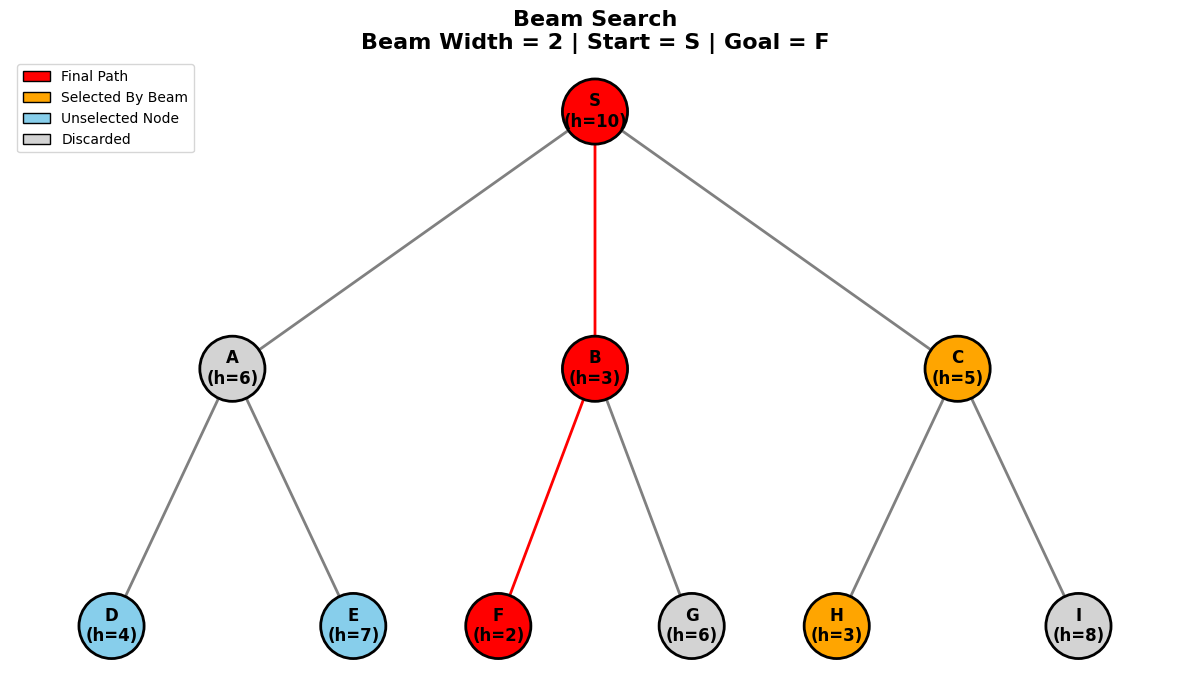

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

def beam_search(graph,heuristic,start,goal,beam_width):
  parent = {start:None}
  beam = [start]
  selected_nodes = {start}
  discarded_nodes = set()
  expanded_nodes = set()
  print("\n==============================")
  print("           BEAM SEARCH")
  print("==============================")

  level = 0
  while beam:
    print(f"\nLevel {level}")
    print("Current Beam:", beam)

    if goal in beam:
      print("\n Goal Found!")
      path =[]
      current = goal

      while current is not None:
        path.append(current)
        current = parent[current]

      path.reverse()

      print("Final Path:", "-> ".join(path))

      return(
          path,
          selected_nodes,
          discarded_nodes,
          expanded_nodes
      )

    candidates=[]

    for node in beam:
      expanded_nodes.add(node)

      for neighbor in graph.get(node, []):
        if neighbor not in selected_nodes:
          candidates.append(neighbor)
          if neighbor not in parent:
            parent[neighbor] = node

    candidates = list(dict.fromkeys(candidates))
    print("Candidates:", candidates)
    candidates.sort(key=lambda x: heuristic[x])
    print(
        "Sorted:",
        [(node, heuristic[node]) for node in candidates]
    )
    new_beam = candidates[:beam_width]
    discarded = candidates[beam_width:]
    discarded_nodes.update(discarded)
    selected_nodes.update(new_beam)

    print(
        "Selected:",
        [(node, heuristic[node]) for node in new_beam]

    )
    print(
        "Discarded:",
        [(node, heuristic[node]) for node in discarded]

    )
    beam = new_beam
    level += 1
  print("\nGoal could not be reached.")
  return(
      None,
      selected_nodes,
      discarded_nodes,
      expanded_nodes
  )
graph = {
    'S': ['A','B', 'C'],
    'A': ['D', 'E'],
    'B': ['F','G'],
    'C': ['H','I'],
    'D':[],
    'E':[],
    'F':[],
    'G':[],
    'H':[],
    'I':[]
}
heuristics ={
    'S': 10,
    'A': 6,
    'B': 3,
    'C': 5,
    'D': 4,
    'E': 7,
    'F': 2,
    'G': 6,
    'H': 3,
    'I': 8
}
start ='S'
goal = 'F'
beam_width = 2

result = beam_search(
    graph,
    heuristics,
    start,
    goal,
    beam_width
)
path, selected_nodes, discarded_nodes, expanded_nodes = result

G = nx.DiGraph()
for node in graph:
  G.add_node(node)
  for neighbor in graph[node]:
    G.add_edge(node, neighbor)
pos = {
        'S':(0, 3),
        'A':(-3,2),
        'B':(0, 2),
        'C':(3, 2),
        'D':(-4, 1),
        'E':(-2, 1),
        'F':(-0.8, 1),
        'G':(0.8, 1),
        'H':(2, 1),
        'I':(4, 1)
    }
node_colors = []
for node in G.nodes():
  if path and node in path:
    node_colors.append('red')
  elif node in selected_nodes:
    node_colors.append('orange')
  elif node in discarded_nodes:
    node_colors.append('lightgray')
  else:
    node_colors.append('skyblue')

edge_colors = []
if path:
  path_edges = set()
  for i in range(len(path) - 1):
    path_edges.add((path[i], path[i+1]))

for u, v in G.edges():
  if (u, v) in path_edges:
    edge_colors.append('red')
  else:
    edge_colors.append('gray')

labels = {}
for node in G.nodes():
  labels[node] = f"{node}\n(h={heuristics[node]})"

plt.figure(figsize=(12, 7))
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    arrows=True,
    arrowsize=20,
    width=2
)

nx.draw_networkx_nodes(
  G,
  pos,
  node_color=node_colors,
  node_size=2200,
  edgecolors="black",
  linewidths=2
)
nx.draw_networkx_labels(
    G,
    pos,
    labels,
    font_size=12,
    font_weight="bold"
  )
plt.title(
    f"Beam Search\n"
    f"Beam Width = {beam_width} | "
    f"Start = {start} | Goal = {goal}",
    fontsize=16,
    fontweight="bold"
  )
from matplotlib.patches import Patch
legend_elements = [
  Patch(facecolor='red', edgecolor='black', label='Final Path'),
  Patch(facecolor='orange', edgecolor='black', label='Selected By Beam'),
  Patch(facecolor='skyblue', edgecolor='black', label='Unselected Node'),
  Patch(facecolor='lightgray', edgecolor='black', label='Discarded')
]
plt.legend(handles=legend_elements, loc='upper left')
plt.axis('off')
plt.tight_layout()
plt.show()